In [1]:
!pip install -q transformer-lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 80.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 22.6 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from transformer_lens import HookedTransformer

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

In [3]:
model = HookedTransformer.from_pretrained(
    "gpt2",
    device=device
)

model.eval()

print("Model loaded.")
print("Number of layers:", model.cfg.n_layers)
print("Number of heads:", model.cfg.n_heads)
print("Hidden dimension:", model.cfg.d_model)

/tmp/ipykernel_59/708463653.py:1: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Model loaded.
Number of layers: 12
Number of heads: 12
Hidden dimension: 768


In [ ]:
NAMES = [
    "Alice",
    "Bob",
    "Carol",
    "Dave",
    "Emma",
    "Frank",
    "Grace",
    "Henry",
    "Ivy",
    "Jack",
    "Kate",
    "Liam",
    "Mary",
    "Nick",
    "Olivia",
    "Paul",
    "Rachel",
    "Sam",
    "Tom",
    "Victor",
    "Wendy"
]



In [5]:
TEMPLATES = [
    "When {A} and {B} went to the store, {B} gave a book to",
    "When {A} and {B} went to the park, {B} handed a gift to",
    "After {A} and {B} finished dinner, {B} gave the keys to",
    "When {A} and {B} arrived at school, {B} showed the picture to",
    "After {A} and {B} met at the station, {B} gave the ticket to",
    "When {A} and {B} went shopping, {B} gave the bag to",
]

In [6]:
def generate_clean_example(A, B, template):
    prompt = template.format(A=A, B=B)
    
    return {
        "prompt": prompt,
        "correct": A,
        "incorrect": B,
        "A": A,
        "B": B,
    }

In [7]:
examples = []

for _ in range(1000):
    A, B = random.sample(NAMES, 2)
    template = random.choice(TEMPLATES)
    
    examples.append(
        generate_clean_example(A, B, template)
    )

df = pd.DataFrame(examples)

df.head()

,prompt,correct,incorrect,A,B
0,"When Wendy and Dave went to the store, Dave ga...",Wendy,Dave,Wendy,Dave
1,"When Ivy and Henry went to the park, Henry han...",Ivy,Henry,Ivy,Henry
2,"When Emma and Dave went shopping, Dave gave th...",Emma,Dave,Emma,Dave
3,"After Sam and Carol met at the station, Carol ...",Sam,Carol,Sam,Carol
4,"When Nick and Bob went to the store, Bob gave ...",Nick,Bob,Nick,Bob


In [8]:
def make_corrupted_example(row):
    A = row["A"]
    B = row["B"]
    
    template = random.choice(TEMPLATES)
    
    corrupted_prompt = template.format(
        A=A,
        B=B
    ).replace(f"{B} gave", f"{A} gave") \
     .replace(f"{B} handed", f"{A} handed") \
     .replace(f"{B} showed", f"{A} showed")
    
    return corrupted_prompt

In [9]:
examples = []

for _ in range(1000):
    A, B = random.sample(NAMES, 2)
    template = random.choice(TEMPLATES)
    
    clean_prompt = template.format(A=A, B=B)
    
    # Swap the semantic roles
    corrupted_prompt = template.format(A=B, B=A)
    
    examples.append({
        "clean_prompt": clean_prompt,
        "corrupted_prompt": corrupted_prompt,
        "clean_correct": A,
        "clean_incorrect": B,
        "corrupted_correct": B,
        "corrupted_incorrect": A,
        "A": A,
        "B": B,
        "template": template
    })

df = pd.DataFrame(examples)



In [10]:
df.head()

,clean_prompt,corrupted_prompt,clean_correct,clean_incorrect,corrupted_correct,corrupted_incorrect,A,B,template
0,"When Carol and Frank arrived at school, Frank ...","When Frank and Carol arrived at school, Carol ...",Carol,Frank,Frank,Carol,Carol,Frank,"When {A} and {B} arrived at school, {B} showed..."
1,"After Olivia and Sam met at the station, Sam g...","After Sam and Olivia met at the station, Olivi...",Olivia,Sam,Sam,Olivia,Olivia,Sam,"After {A} and {B} met at the station, {B} gave..."
2,"When Rachel and Nick went to the store, Nick g...","When Nick and Rachel went to the store, Rachel...",Rachel,Nick,Nick,Rachel,Rachel,Nick,"When {A} and {B} went to the store, {B} gave a..."
3,"After Alice and Carol finished dinner, Carol g...","After Carol and Alice finished dinner, Alice g...",Alice,Carol,Carol,Alice,Alice,Carol,"After {A} and {B} finished dinner, {B} gave th..."
4,"After Sam and Carol met at the station, Carol ...","After Carol and Sam met at the station, Sam ga...",Sam,Carol,Carol,Sam,Sam,Carol,"After {A} and {B} met at the station, {B} gave..."


In [11]:
for i in range(5):
    row = df.iloc[i]
    
    print("=" * 80)
    print("CLEAN:")
    print(row["clean_prompt"])
    print("Correct:", row["clean_correct"])
    
    print("\nCORRUPTED:")
    print(row["corrupted_prompt"])
    print("Correct:", row["corrupted_correct"])

CLEAN:
When Carol and Frank arrived at school, Frank showed the picture to
Correct: Carol

CORRUPTED:
When Frank and Carol arrived at school, Carol showed the picture to
Correct: Frank
CLEAN:
After Olivia and Sam met at the station, Sam gave the ticket to
Correct: Olivia

CORRUPTED:
After Sam and Olivia met at the station, Olivia gave the ticket to
Correct: Sam
CLEAN:
When Rachel and Nick went to the store, Nick gave a book to
Correct: Rachel

CORRUPTED:
When Nick and Rachel went to the store, Rachel gave a book to
Correct: Nick
CLEAN:
After Alice and Carol finished dinner, Carol gave the keys to
Correct: Alice

CORRUPTED:
After Carol and Alice finished dinner, Alice gave the keys to
Correct: Carol
CLEAN:
After Sam and Carol met at the station, Carol gave the ticket to
Correct: Sam

CORRUPTED:
After Carol and Sam met at the station, Sam gave the ticket to
Correct: Carol


In [16]:
for name in NAMES:
    tokens = model.to_str_tokens(" " + name)
    print(f"{name:10s} -> {tokens}")

Alice      -> ['<|endoftext|>', ' Alice']
Bob        -> ['<|endoftext|>', ' Bob']
Carol      -> ['<|endoftext|>', ' Carol']
Dave       -> ['<|endoftext|>', ' Dave']
Emma       -> ['<|endoftext|>', ' Emma']
Frank      -> ['<|endoftext|>', ' Frank']
Grace      -> ['<|endoftext|>', ' Grace']
Henry      -> ['<|endoftext|>', ' Henry']
Ivy        -> ['<|endoftext|>', ' Ivy']
Jack       -> ['<|endoftext|>', ' Jack']
Kate       -> ['<|endoftext|>', ' Kate']
Liam       -> ['<|endoftext|>', ' Liam']
Mary       -> ['<|endoftext|>', ' Mary']
Nick       -> ['<|endoftext|>', ' Nick']
Olivia     -> ['<|endoftext|>', ' Olivia']
Paul       -> ['<|endoftext|>', ' Paul']
Rachel     -> ['<|endoftext|>', ' Rachel']
Sam        -> ['<|endoftext|>', ' Sam']
Tom        -> ['<|endoftext|>', ' Tom']
Victor     -> ['<|endoftext|>', ' Victor']
Wendy      -> ['<|endoftext|>', ' Wendy']


In [18]:
def get_logit_difference(logits, correct_token, incorrect_token):
    
    correct_id = get_name_token_id(correct_token)
    incorrect_id = get_name_token_id(incorrect_token)
    
    correct_logit = logits[0, -1, correct_id]
    incorrect_logit = logits[0, -1, incorrect_id]
    
    return (
        correct_logit - incorrect_logit
    ).item()

In [17]:
def get_name_token_id(name):
    return model.to_single_token(" " + name)

In [19]:
row = df.iloc[0]

clean_prompt = row["clean_prompt"]

tokens = model.to_tokens(clean_prompt)

with torch.no_grad():
    logits = model(tokens)

ld = get_logit_difference(
    logits,
    row["clean_correct"],
    row["clean_incorrect"]
)

print(clean_prompt)
print("Correct:", row["clean_correct"])
print("Incorrect:", row["clean_incorrect"])
print("Logit difference:", ld)

When Carol and Frank arrived at school, Frank showed the picture to
Correct: Carol
Incorrect: Frank
Logit difference: 3.583780288696289


In [22]:
def evaluate_clean_example(row):
    tokens = model.to_tokens(row["clean_prompt"])
    
    with torch.no_grad():
        logits = model(tokens)
    
    correct_id = get_name_token_id(row["clean_correct"])
    incorrect_id = get_name_token_id(row["clean_incorrect"])
    
    correct_logit = logits[0, -1, correct_id].item()
    incorrect_logit = logits[0, -1, incorrect_id].item()
    
    return correct_logit - incorrect_logit

In [23]:
df_eval = df.iloc[:200].copy()

df_eval["clean_logit_diff"] = [
    evaluate_clean_example(row)
    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval))
]

  0%|          | 0/200 [00:00<?, ?it/s]

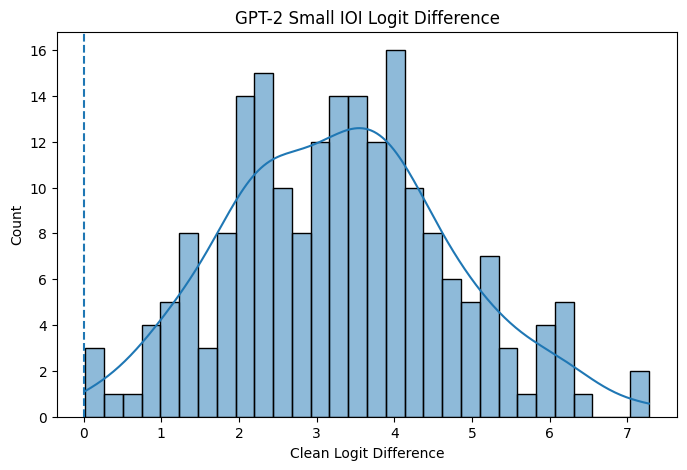

In [24]:


plt.figure(figsize=(8, 5))

sns.histplot(
    df_eval["clean_logit_diff"],
    bins=30,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Clean Logit Difference")
plt.ylabel("Count")
plt.title("GPT-2 Small IOI Logit Difference")

plt.show()

In [25]:
df_eval["clean_correct_prediction"] = (
    df_eval["clean_logit_diff"] > 0
)

accuracy = df_eval["clean_correct_prediction"].mean()

print(f"Clean IOI accuracy: {accuracy:.3f}")

Clean IOI accuracy: 1.000


In [26]:
df.to_csv(
    "ioi_synthetic_dataset.csv",
    index=False
)

print("Saved dataset.")

Saved dataset.
